# Graficando los resultados del entrenamiento y zero shot

Importar librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error, r2_score



## Zero shot

In [ ]:
url = "https://raw.githubusercontent.com/benjaminhurbe/250610_esm3/refs/heads/main/results/compute_zero_shot_results/A0A1K4LHP2_CR9114_Phillips_2021_updated_target.csv"
df = pd.read_csv(url)
df = df.rename(columns={'DMS_score': 'kd', 'ESM3_open_score': 'pred_kd'})
df.head()

,mutant,mutated_sequence,DMS_score,ESM3_open_score
0,S29F:S52I:S57T:T58A:I74K:T87R:S106Y,QVQLVQSGAEVKKPGSSVKVSCKASGGTSSSYAISWVRQAPGQGLE...,9.484586,16.332031
1,S52I:S57T:T58A:A59N:S71T:I74K:N77S:N84S:F95Y:S...,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,9.430991,23.458984
2,S29F:N30S:N31S:S52I:S57T:T58A:I74K:N77S:N84S:T...,QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLE...,9.497006,24.152344
3,S29F:N31S:S52I:S57T:T58A:A59N:S71T:I74K:S76T:N...,QVQLVQSGAEVKKPGSSVKVSCKASGGTSSNYAISWVRQAPGQGLE...,9.499691,28.306641
4,S29F:N30S:N31S:S52I:S57T:A59N:I74K:T87R:F95Y:S...,QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLE...,9.380737,27.298828


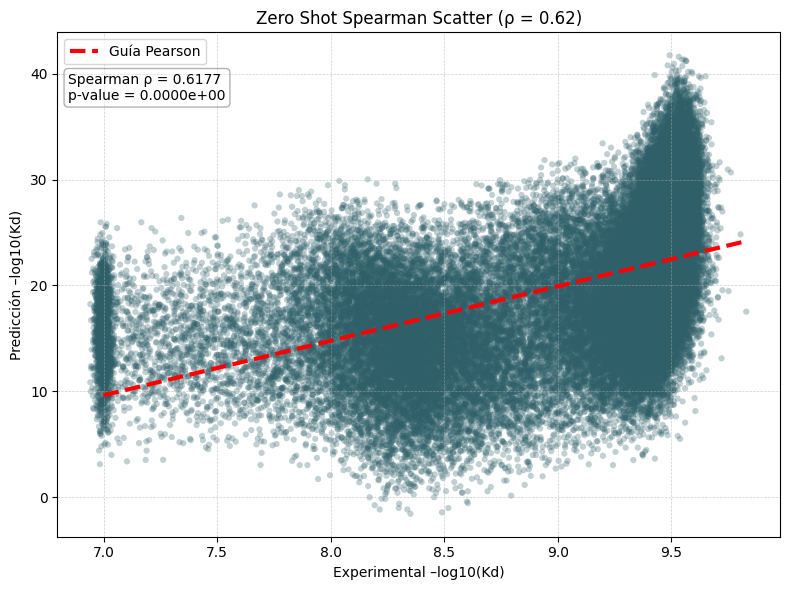

In [ ]:
# — Scatter Spearman final
final_spearman, p_value = spearmanr(df["kd"], df["pred_kd"])
x = df["kd"]
y = df["pred_kd"]
jitter = np.random.normal(loc=0.0, scale=0.02, size=len(x))
x_j = x + jitter

plt.figure(figsize=(8,6))
plt.scatter(x_j, y, s=20, alpha=0.3, edgecolors='none', color = "#2f606a")
m, b = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, m*xx + b, linestyle='--', linewidth=3, label='Guía Pearson', color = 'red')
plt.title(f'Zero Shot Spearman Scatter (ρ = {final_spearman:.2f})')
plt.xlabel('Experimental –log10(Kd)')
plt.ylabel('Predicción –log10(Kd)')
plt.legend(); plt.grid(ls='--', lw=0.5, alpha=0.6)
plt.tight_layout()
# Añadir cuadro de texto con la correlación en la esquina
textstr = f'Spearman ρ = {final_spearman:.4f}\np-value = {p_value:.4e}'
props = dict(boxstyle='round', facecolor='white', alpha=0.3)
plt.text(0.015, 0.92, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)
#----------------------
plt.savefig("spearman_scatter_normalized_zero_shot.png", dpi=300)
plt.show()

## Transfer learning sin normalizar


In [3]:
url = "https://raw.githubusercontent.com/benjaminhurbe/250610_esm3/refs/heads/main/results/transfer_learning_regression_head/test_predictions.csv"
notnorm_df = pd.read_csv(url)
notnorm_df.head()

,sequence,kd,pred_kd
0,QVQLVQSGAEVKKPGSSVKVSCKASGGTSNSYAISWVRQAPGQGLE...,9.283864,8.786882
1,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,9.412434,9.330459
2,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,9.392823,9.424065
3,QVQLVQSGAEVKKPGSSVKVSCKASGGTSNSYAISWVRQAPGQGLE...,7.267199,7.755698
4,QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLE...,8.882481,8.451210


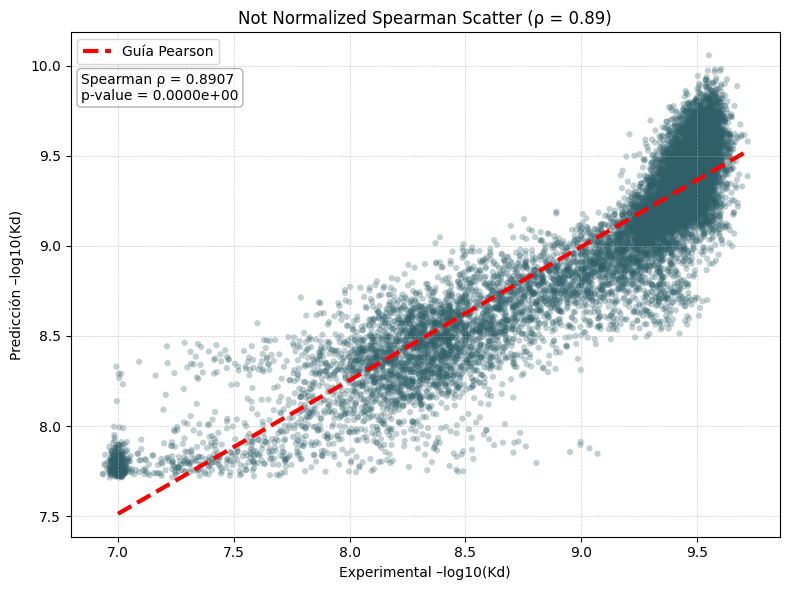

In [4]:
# — Scatter Spearman final
final_spearman, p_value = spearmanr(notnorm_df["kd"], notnorm_df["pred_kd"])
x = notnorm_df["kd"]
y = notnorm_df["pred_kd"]
jitter = np.random.normal(loc=0.0, scale=0.02, size=len(x))
x_j = x + jitter

plt.figure(figsize=(8,6))
plt.scatter(x_j, y, s=20, alpha=0.3, edgecolors='none', color = "#2f606a")
m, b = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, m*xx + b, linestyle='--', linewidth=3, label='Guía Pearson', color = 'red')
plt.title(f'Not Normalized Spearman Scatter (ρ = {final_spearman:.2f})')
plt.xlabel('Experimental –log10(Kd)')
plt.ylabel('Predicción –log10(Kd)')
plt.legend(); plt.grid(ls='--', lw=0.5, alpha=0.6)
plt.tight_layout()
# Añadir cuadro de texto con la correlación en la esquina
textstr = f'Spearman ρ = {final_spearman:.4f}\np-value = {p_value:.4e}'
props = dict(boxstyle='round', facecolor='white', alpha=0.3)
plt.text(0.015, 0.92, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)
#----------------------
plt.savefig("spearman_scatter_tf_not_normalized.png", dpi=300)
plt.show()

## Scatter spearman normalizado

In [ ]:
url = "https://raw.githubusercontent.com/benjaminhurbe/250610_esm3/refs/heads/main/results/transfer_learning_regression_normalized/test_predictions_normalized.csv"
out_df = pd.read_csv(url)
out_df.head()

,sequence,kd,kd_scaled,pred_scaled,pred_kd
0,QVQLVQSGAEVKKPGSSVKVSCKASGGTSNSYAISWVRQAPGQGLE...,9.283864,0.377659,0.026489,9.059680
1,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,9.412434,0.579056,0.540444,9.387784
2,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,9.392823,0.548337,0.448226,9.328913
3,QVQLVQSGAEVKKPGSSVKVSCKASGGTSNSYAISWVRQAPGQGLE...,7.267199,-2.781325,-2.282180,7.585848
4,QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLE...,8.882481,-0.251082,-0.612159,8.651974


transfer learning normalizado

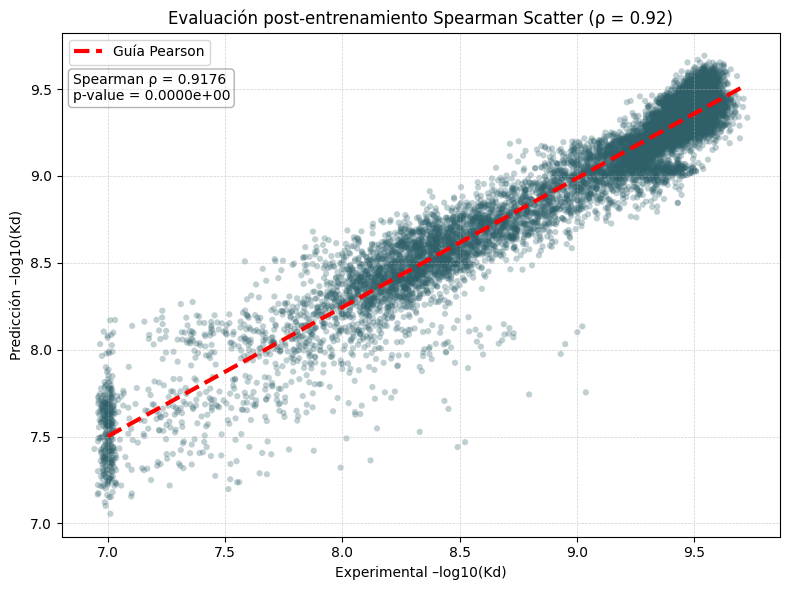

In [ ]:
# ────────────────────────────────────────────────────────────────────────
#  7) Graficar todas las curvas y el scatter de Spearman
# ────────────────────────────────────────────────────────────────────────

# — Scatter Spearman final
x = out_df["kd"]
y = out_df["pred_kd"]
jitter = np.random.normal(loc=0.0, scale=0.02, size=len(x))
x_j = x + jitter

final_spearman, p_value = spearmanr(out_df["kd"], out_df["pred_kd"])
plt.figure(figsize=(8,6))
plt.scatter(x_j, y, s=20, alpha=0.3, edgecolors='none', color = "#2f606a")
m, b = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, m*xx + b, linestyle='--', linewidth=3, label='Guía Pearson', color = 'red')
plt.title(f'Evaluación post-entrenamiento Spearman Scatter (ρ = {final_spearman:.2f})')
plt.xlabel('Experimental –log10(Kd)')
plt.ylabel('Predicción –log10(Kd)')
plt.legend(); plt.grid(ls='--', lw=0.5, alpha=0.6)
plt.tight_layout()
# Añadir cuadro de texto con la correlación en la esquina
textstr = f'Spearman ρ = {final_spearman:.4f}\np-value = {p_value:.4e}'
props = dict(boxstyle='round', facecolor='white', alpha=0.3)
plt.text(0.015, 0.92, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)
#----------------------
plt.savefig("spearman_scatter_tf_normalized.png", dpi=300)
plt.show()